In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Charger le dataset
data = pd.read_csv(r"C:\Users\hp\Downloads\Crop_recommendation.csv")

# 2. Séparer features et labels
X = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]
y = df["label"]

# 3. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Créer le modèle
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# 5. Entraîner
model.fit(X_train, y_train)

# 6. Prédire
y_pred = model.predict(X_test)

# 7. Évaluer
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9931818181818182
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

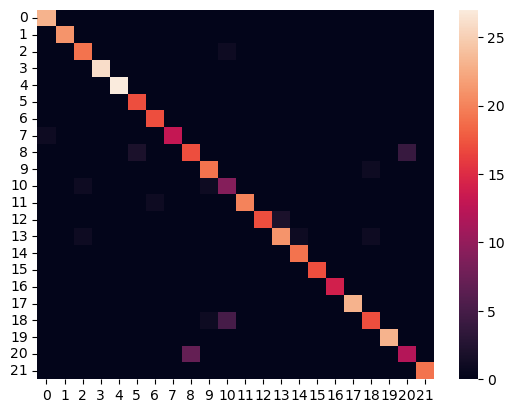

In [36]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=False)
plt.show()

In [37]:
import joblib
joblib.dump(model, 'crop_model.pkl')
print("Modèle sauvegardé dans crop_model.pkl")

Modèle sauvegardé dans crop_model.pkl


In [53]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load(r"C:\Users\hp\crop_model.pkl")

# Exemple réaliste
new_data = pd.DataFrame({
    "N": [70],
    "P": [30],
    "K": [40],
    "temperature": [25],
    "humidity": [80],
    "ph": [7],
    "rainfall": [250]
})

# top-3 prédiction
proba = model.predict_proba(new_data)[0]
classes = model.classes_
top3 = np.argsort(proba)[-3:][::-1]

print("Top 3:")
for i in top3:
    print(f"{classes[i]} ({proba[i]*100:.2f}%)")


Top 3:
rice (40.75%)
watermelon (15.75%)
coffee (15.00%)
